# Coherent Phonon Graphs

**Import Libraries**

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

**Download File**


In [3]:
col_names = ['Position(mm)', 'Voltage(V)', 'Phase(Theta)'] # Assign custom names

metal = "bismuth" # Choose metal (bismuth or antimony)

power = "104.6" # Choose power

df = pd.read_csv(f"{metal}/power/data/{power}.txt", sep=r"\s+", header=None, names=col_names)

**Constants**

In [4]:
# speed of light
c = 299792458

# trial length (bismuth: 81, antimony: 161)
trial_len = -1 
if metal == "bismuth":
    trial_len = 81
if metal == "antimony":
    trial_len = 161

**Create Arrays**

In [7]:
position = df["Position(mm)"]
voltage = df["Voltage(V)"] 
time = 2 * (position / 10**3) / c
# Convert voltage from volts to microvolts (10^-6)
voltage = voltage * 10**6

# Convert time from seconds to picoseconds (10^-12)
time = time * 10**12


0      1.384291e-10
1      1.385078e-10
2      1.385872e-10
3      1.386666e-10
4      1.387460e-10
           ...     
157    1.444499e-10
158    1.445293e-10
159    1.446080e-10
160    1.446874e-10
161    1.447668e-10
Name: Position(mm), Length: 162, dtype: float64


**Average Trials**

In [8]:
# Separate and average trial runs for each power and each sample

average_voltage = voltage.groupby(voltage.index % trial_len).mean().reset_index(drop=True)
time_trunc = time[ : trial_len]

**Plot Data**

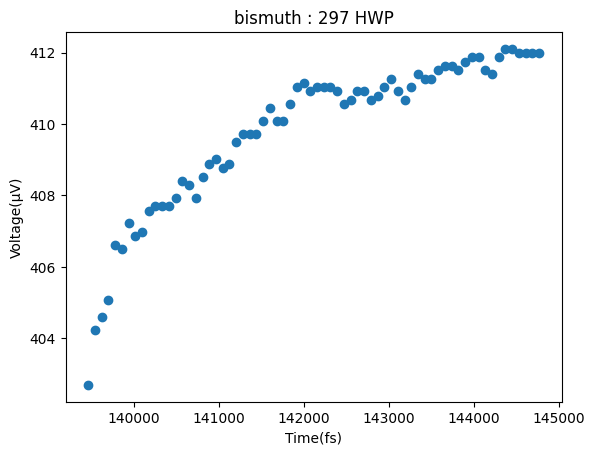

In [14]:
plt.figure()
plt.scatter(time_trunc, average_voltage)
plt.xlabel("Time(ps)")
plt.ylabel(f"Voltage(\u00B5V)")
plt.title(f"{metal} (power : {power} mW)")

plt.show()

**Perform Exponential Regression**

Workflow
1. Libraries
2. Helper functions
3. Download .txt files and store as dataframes
4. Split each data frame into separate files (81 data points per file), store in set/list/array
5. Separate columns (position & voltage) from dataframe, create time dataframe, scale to microvolts & femtoseconds
6. Average trials for each power, produce mean graphs, with error bars
7. Find amplitude of sinusoidal oscillations and exponential reduction
8. Decide how to compare power graphs

